# Phase 4: Exploratory Data Analysis
## Bengaluru Metro Analytics Project

**Objective:** Explore real BMRCL ridership patterns visually and statistically.
Surface findings that will drive dashboard design and business recommendations.

**Data:** Aug–Sep 2025, 83 stations, Purple/Green/Yellow lines, entry + exit counts

**Analysis sections:**
1. Network overview
2. Station-level performance
3. Time patterns & peak hours
4. Line comparison
5. Anomaly detection

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sqlalchemy import create_engine, text
import warnings
warnings.filterwarnings('ignore')

# Chart styling - apply once, affects all plots
plt.rcParams['figure.facecolor'] = '#0f0f0f'
plt.rcParams['axes.facecolor'] = '#1a1a1a'
plt.rcParams['axes.edgecolor'] = '#444444'
plt.rcParams['axes.labelcolor'] = 'white'
plt.rcParams['text.color'] = 'white'
plt.rcParams['xtick.color'] = 'white'
plt.rcParams['ytick.color'] = 'white'
plt.rcParams['grid.color'] = '#333333'
plt.rcParams['grid.linestyle'] = '--'
plt.rcParams['grid.alpha'] = 0.5
plt.rcParams['font.family'] = 'sans-serif'

# Line colours - consistent across all charts
LINE_COLORS = {
    'Purple': '#9b59b6',
    'Green':  '#2ecc71',
    'Yellow': '#f1c40f'
}

print("Libraries loaded ✓")

Libraries loaded ✓


In [2]:
engine = create_engine(
     "postgresql+psycopg2://postgres@localhost:5433/postgres",
     connect_args={"password": "mintee@12345T"}
)

df = pd.read_sql("SELECT * FROM metro.ridership", engine)
df['date'] = pd.to_datetime(df['date'])

print(f"Rows loaded:       {len(df):,}")
print(f"Stations:          {df['station_name'].nunique()}")
print(f"Date range:        {df['date'].min().date()} to {df['date'].max().date()}")
print(f"Transaction types: {df['transaction_type'].unique()}")
print(f"Lines:             {df['line'].unique()}")

Rows loaded:       6,335
Stations:          84
Date range:        2025-08-01 to 2025-09-30
Transaction types: <StringArray>
['Entry', 'Exit']
Length: 2, dtype: str
Lines:             <StringArray>
['Purple', 'Green', 'Yellow']
Length: 3, dtype: str


## Section 1: Network Overview

**Question:** What does total daily ridership look like across the network?
How does the overall trend behave over Aug–Sep 2025?

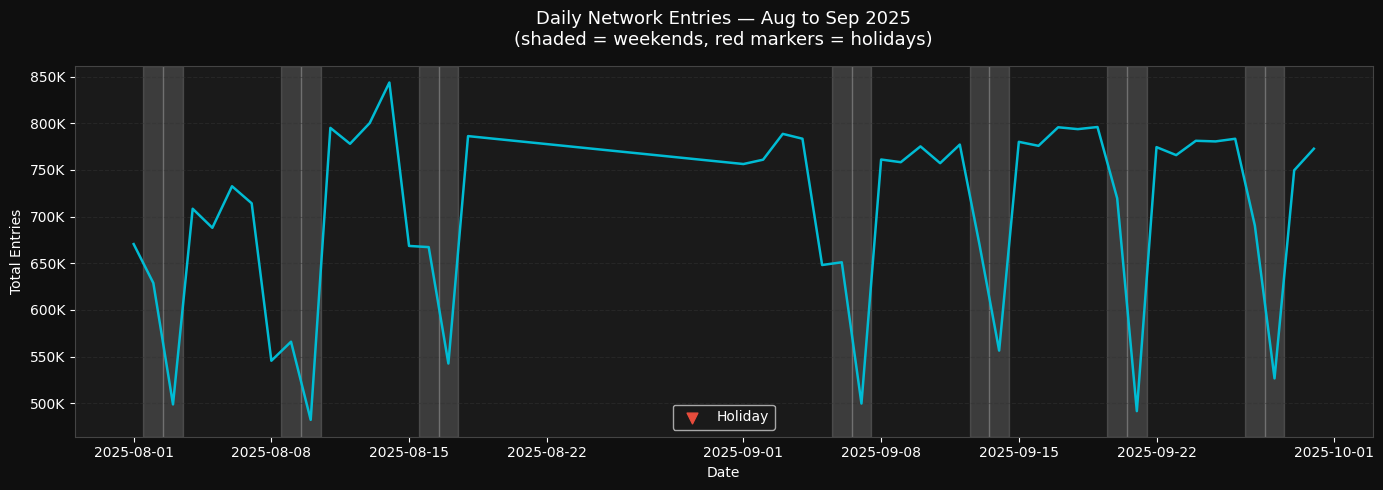

Saved: reports/01_daily_network_trend.png


In [3]:
# Aggregate: total network entries per day
daily_network = (
     df[df['transaction_type'] == 'Entry']
     .groupby(['date', 'is_weekend', 'is_holiday'])['daily_count']
     .sum()
     .reset_index()
     .rename(columns={'daily_count': 'network_entries'})
)

fig, ax = plt.subplots(figsize=(14, 5))

# Plot line
ax.plot(daily_network['date'], daily_network['network_entries'],
          color='#00bcd4', linewidth=1.8, zorder=3)

# Shade weekends
for _, row in daily_network[daily_network['is_weekend']].iterrows():
     ax.axvspan(row['date'] - pd.Timedelta(hours=12),
               row['date'] + pd.Timedelta(hours=12),
               alpha=0.15, color='#ffffff', zorder=1)

# Mark holidays
holidays = daily_network[daily_network['is_holiday']]
ax.scatter(holidays['date'], holidays['network_entries'],
          color='#e74c3c', zorder=5, s=60, label='Holiday', marker='v')

# Formatting
ax.yaxis.set_major_formatter(mticker.FuncFormatter(
     lambda x, _: f'{x/1e6:.2f}M' if x >= 1e6 else f'{x/1e3:.0f}K'))
ax.set_title('Daily Network Entries — Aug to Sep 2025\n(shaded = weekends, red markers = holidays)',
          fontsize=13, pad=15)
ax.set_xlabel('Date')
ax.set_ylabel('Total Entries')
ax.legend()
ax.grid(True, axis='y')

plt.tight_layout()
plt.savefig('../reports/01_daily_network_trend.png', dpi=150,
          bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print("Saved: reports/01_daily_network_trend.png")

## Section 2: Station-Level Performance

**Question:** Which stations dominate ridership?
How concentrated is the network around a few key stations?

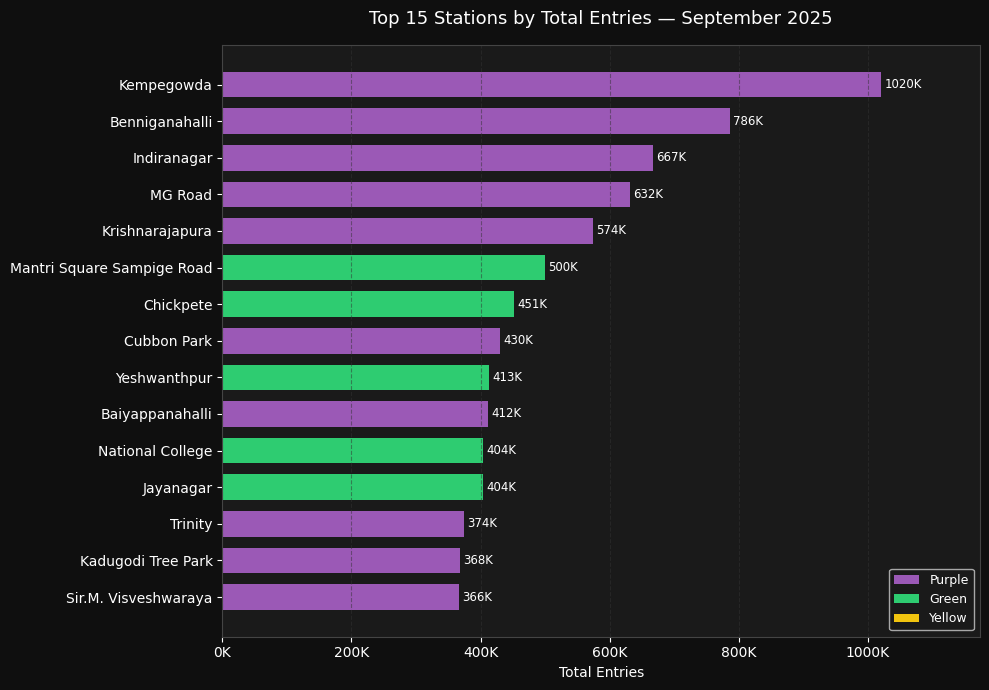

Saved: reports/02_top15_stations.png


In [4]:
# Top 15 stations by total entries in Sep (full month)
top15 = (
     df[(df['transaction_type'] == 'Entry') & (df['date'].dt.month == 9)]
     .groupby(['station_name', 'line'])['daily_count']
     .sum()
     .reset_index()
     .sort_values('daily_count', ascending=True)
     .tail(15)
)

fig, ax = plt.subplots(figsize=(10, 7))

colors = [LINE_COLORS.get(line, '#888888') for line in top15['line']]
bars = ax.barh(top15['station_name'], top15['daily_count'],
               color=colors, edgecolor='none', height=0.7)

# Value labels
for bar, val in zip(bars, top15['daily_count']):
     ax.text(bar.get_width() + 5000, bar.get_y() + bar.get_height()/2,
          f'{val/1000:.0f}K', va='center', fontsize=8.5, color='white')

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=l) for l, c in LINE_COLORS.items()]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)

ax.set_title('Top 15 Stations by Total Entries — September 2025',
          fontsize=13, pad=15)
ax.set_xlabel('Total Entries')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
ax.grid(True, axis='x')
ax.set_xlim(0, top15['daily_count'].max() * 1.15)

plt.tight_layout()
plt.savefig('../reports/02_top15_stations.png', dpi=150,
          bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print("Saved: reports/02_top15_stations.png")

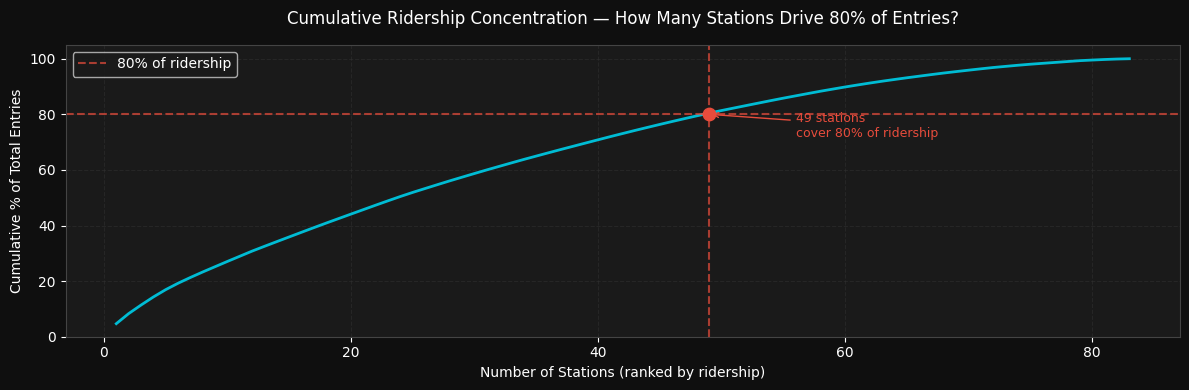

Top 10 stations account for 27.1% of total network entries
80% of ridership is covered by 49 stations out of 83


In [5]:
# What % of ridership do top 10 stations account for?
station_totals = (
     df[(df['transaction_type'] == 'Entry') & (df['date'].dt.month == 9)]
     .groupby('station_name')['daily_count']
     .sum()
     .sort_values(ascending=False)
     .reset_index()
)

station_totals['cumulative_pct'] = (

station_totals['daily_count'].cumsum() /
    station_totals['daily_count'].sum() * 100
)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(range(1, len(station_totals)+1),
          station_totals['cumulative_pct'],
          color='#00bcd4', linewidth=2)

# Mark the 80% threshold
idx_80 = (station_totals['cumulative_pct'] >= 80).idxmax()
ax.axhline(80, color='#e74c3c', linestyle='--', alpha=0.7, label='80% of ridership')
ax.axvline(idx_80 + 1, color='#e74c3c', linestyle='--', alpha=0.7)
ax.scatter([idx_80 + 1], [80], color='#e74c3c', s=80, zorder=5)
ax.annotate(f'{idx_80+1} stations\ncover 80% of ridership',
               xy=(idx_80+1, 80), xytext=(idx_80+8, 72),
               color='#e74c3c', fontsize=9,
               arrowprops=dict(arrowstyle='->', color='#e74c3c'))

ax.set_title('Cumulative Ridership Concentration — How Many Stations Drive 80% of Entries?',
          fontsize=12, pad=15)
ax.set_xlabel('Number of Stations (ranked by ridership)')
ax.set_ylabel('Cumulative % of Total Entries')
ax.legend()
ax.grid(True)
ax.set_ylim(0, 105)

plt.tight_layout()
plt.savefig('../reports/03_ridership_concentration.png', dpi=150,
          bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()

top10_pct = station_totals.iloc[9]['cumulative_pct']
print(f"Top 10 stations account for {top10_pct:.1f}% of total network entries")
print(f"80% of ridership is covered by {idx_80+1} stations out of {len(station_totals)}")

## Section 3: Time Patterns & Peak Hours

**Question:** When do passengers travel?
What does the AM and PM peak look like across the network?
Understanding this directly informs train frequency decisions.

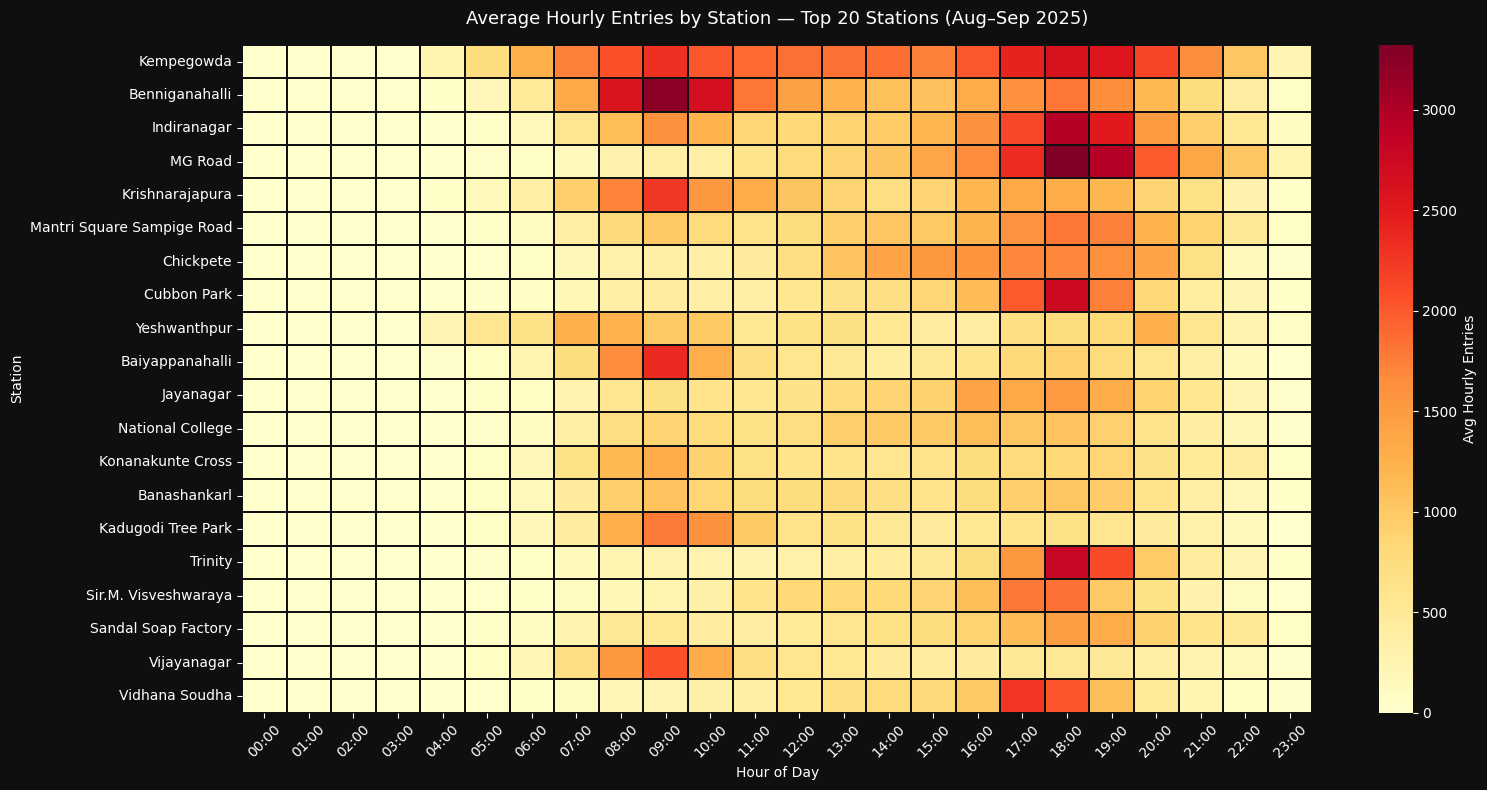

Saved: reports/04_hourly_heatmap.png


In [6]:
# Melt hourly columns into long format
hour_cols = [f'h{str(i).zfill(2)}' for i in range(24)]

df_entry = df[df['transaction_type'] == 'Entry'].copy()

# Average hourly entries per station across all days
hourly_avg = (
     df_entry.groupby('station_name')[hour_cols]
     .mean()
)

# Pick top 20 stations by total for readability
top20 = (
     df_entry.groupby('station_name')['daily_count']
     .sum()
     .nlargest(20)
     .index
)
hourly_top20 = hourly_avg.loc[top20]

# Rename columns for display
hourly_top20.columns = [f'{i:02d}:00' for i in range(24)]

fig, ax = plt.subplots(figsize=(16, 8))
sns.heatmap(
     hourly_top20,
     cmap='YlOrRd',
     ax=ax,
     linewidths=0.3,
     linecolor='#111111',
     cbar_kws={'label': 'Avg Hourly Entries'}
)

ax.set_title('Average Hourly Entries by Station — Top 20 Stations (Aug–Sep 2025)',
          fontsize=13, pad=15)
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Station')
plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.savefig('../reports/04_hourly_heatmap.png', dpi=150,
          bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print("Saved: reports/04_hourly_heatmap.png")

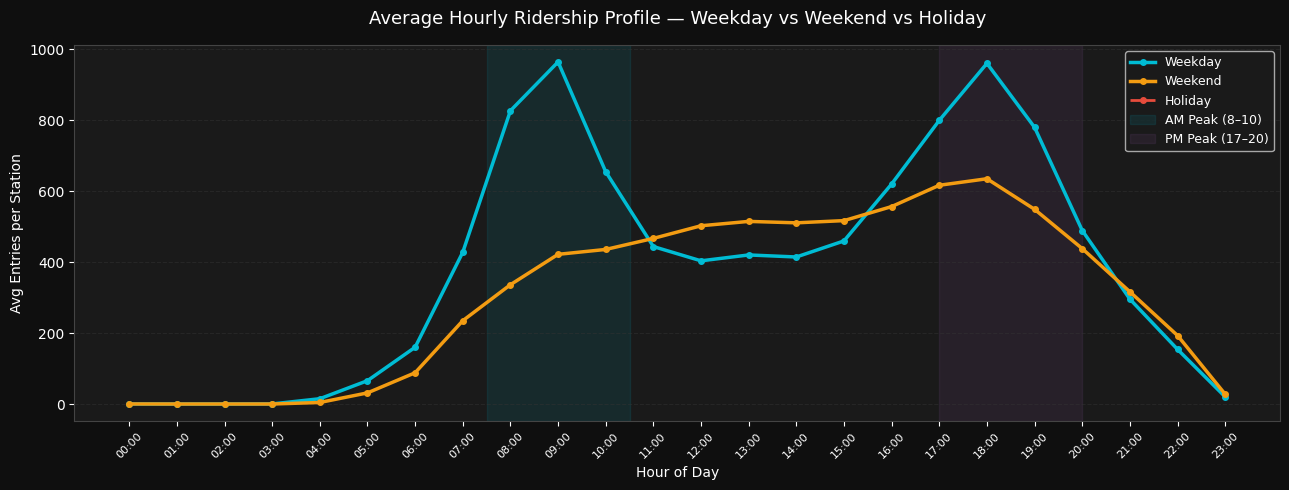

Saved: reports/05_hourly_profile.png


In [7]:
# Average hourly profile: weekday vs weekend (network total)
def hourly_profile(df_subset):
     return df_subset[hour_cols].mean()

weekday = hourly_profile(df_entry[~df_entry['is_weekend'] & ~df_entry['is_holiday']])
weekend = hourly_profile(df_entry[df_entry['is_weekend']])
holiday = hourly_profile(df_entry[df_entry['is_holiday']])

hours = list(range(24))
fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(hours, weekday.values, color='#00bcd4', linewidth=2.5,
     label='Weekday', marker='o', markersize=4)
ax.plot(hours, weekend.values, color='#f39c12', linewidth=2.5,
     label='Weekend', marker='o', markersize=4)
if len(holiday) > 0:
     ax.plot(hours, holiday.values, color='#e74c3c', linewidth=2,
          label='Holiday', linestyle='--', marker='o', markersize=4)

# Shade AM and PM peak windows
ax.axvspan(7.5, 10.5, alpha=0.1, color='#00bcd4', label='AM Peak (8–10)')
ax.axvspan(17, 20, alpha=0.1, color='#9b59b6', label='PM Peak (17–20)')

ax.set_xticks(hours)
ax.set_xticklabels([f'{h:02d}:00' for h in hours], rotation=45, fontsize=8)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}'))
ax.set_title('Average Hourly Ridership Profile — Weekday vs Weekend vs Holiday',
          fontsize=13, pad=15)
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Avg Entries per Station')
ax.legend(fontsize=9)
ax.grid(True, axis='y')

plt.tight_layout()
plt.savefig('../reports/05_hourly_profile.png', dpi=150,
          bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print("Saved: reports/05_hourly_profile.png")

## Section 4: Line Comparison

**Question:** How do the Purple, Green, and Yellow lines compare?
Which corridor is most efficient per station?

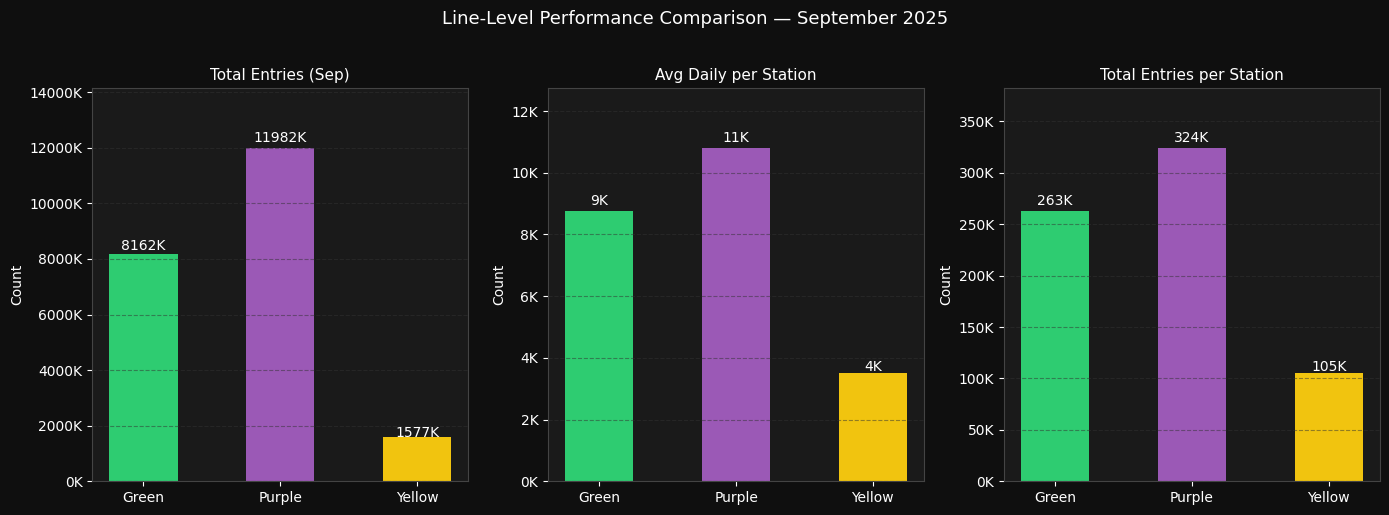

Saved: reports/06_line_comparison.png
  line  total_entries    avg_daily  station_count  entries_per_station
 Green        8162432  8776.808602             31             263304.0
Purple       11981659 10794.287387             37             323829.0
Yellow        1577180  3504.844444             15             105145.0


In [8]:
line_stats = (
     df[(df['transaction_type'] == 'Entry') & (df['date'].dt.month == 9)]
     .groupby('line')
     .agg(
          total_entries=('daily_count', 'sum'),
          avg_daily=('daily_count', 'mean'),
          station_count=('station_name', 'nunique')
     )
     .reset_index()
)
line_stats['entries_per_station'] = (
     line_stats['total_entries'] / line_stats['station_count']
).round(0)

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
metrics = ['total_entries', 'avg_daily', 'entries_per_station']
titles  = ['Total Entries (Sep)', 'Avg Daily per Station', 'Total Entries per Station']

for ax, metric, title in zip(axes, metrics, titles):
     colors = [LINE_COLORS.get(l, '#888') for l in line_stats['line']]
     bars = ax.bar(line_stats['line'], line_stats[metric],
                    color=colors, edgecolor='none', width=0.5)
     for bar, val in zip(bars, line_stats[metric]):
          ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.02,
                    f'{val/1000:.0f}K', ha='center', fontsize=10, color='white')
     ax.set_title(title, fontsize=11)
     ax.set_ylabel('Count')
     ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
     ax.grid(True, axis='y')
     ax.set_ylim(0, line_stats[metric].max() * 1.18)

fig.suptitle('Line-Level Performance Comparison — September 2025',
          fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('../reports/06_line_comparison.png', dpi=150,
          bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print("Saved: reports/06_line_comparison.png")
print(line_stats.to_string(index=False))

## Section 5: Anomaly Detection

**Question:** Are there days where ridership dropped or spiked unexpectedly?
Z-score flags statistically unusual days for investigation.

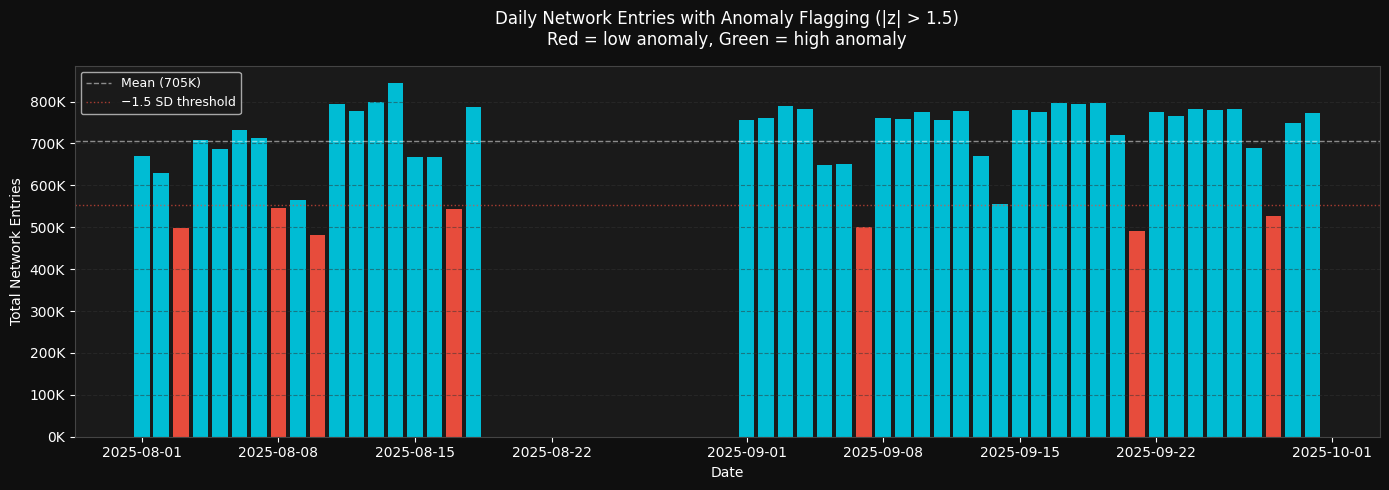


Flagged anomaly days:
      date day_of_week  is_holiday  is_weekend  network_entries  z_score
2025-08-10      Sunday       False        True           482205    -2.21
2025-09-21      Sunday       False        True           491549    -2.12
2025-08-03      Sunday       False        True           498746    -2.05
2025-09-07      Sunday       False        True           499672    -2.04
2025-09-28      Sunday       False        True           526641    -1.77
2025-08-17      Sunday       False        True           542547    -1.61
2025-08-08      Friday       False       False           545543    -1.58


In [9]:
daily_totals = (
     df[df['transaction_type'] == 'Entry']
     .groupby(['date', 'is_weekend', 'is_holiday', 'day_of_week'])['daily_count']
     .sum()
     .reset_index()
     .rename(columns={'daily_count': 'network_entries'})
)

mean_entries = daily_totals['network_entries'].mean()
std_entries  = daily_totals['network_entries'].std()
daily_totals['z_score'] = (
     (daily_totals['network_entries'] - mean_entries) / std_entries
).round(2)

anomalies = daily_totals[daily_totals['z_score'].abs() > 1.5].sort_values('z_score')

fig, ax = plt.subplots(figsize=(14, 5))
colors = daily_totals['z_score'].apply(
     lambda z: '#e74c3c' if z < -1.5 else ('#2ecc71' if z > 1.5 else '#00bcd4')
)
ax.bar(daily_totals['date'], daily_totals['network_entries'],
     color=colors, edgecolor='none', width=0.8)

ax.axhline(mean_entries, color='white', linestyle='--',
          alpha=0.5, linewidth=1, label=f'Mean ({mean_entries/1000:.0f}K)')
ax.axhline(mean_entries - 1.5*std_entries, color='#e74c3c',
          linestyle=':', alpha=0.7, linewidth=1, label='−1.5 SD threshold')

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
ax.set_title('Daily Network Entries with Anomaly Flagging (|z| > 1.5)\nRed = low anomaly, Green = high anomaly',
          fontsize=12, pad=15)
ax.set_xlabel('Date')
ax.set_ylabel('Total Network Entries')
ax.legend(fontsize=9)
ax.grid(True, axis='y')

plt.tight_layout()
plt.savefig('../reports/07_anomaly_detection.png', dpi=150,
          bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()

print("\nFlagged anomaly days:")
print(anomalies[['date', 'day_of_week', 'is_holiday',
               'is_weekend', 'network_entries', 'z_score']].to_string(index=False))

## EDA Summary — Key Findings

Document your findings here after running all cells.

In [10]:
print("=" * 55)
print("EDA KEY FINDINGS — BENGALURU METRO AUG-SEP 2025")
print("=" * 55)

top_station = (
     df[(df['transaction_type'] == 'Entry') & (df['date'].dt.month == 9)]
     .groupby('station_name')['daily_count'].sum()
     .idxmax()
)
top_station_val = (
     df[(df['transaction_type'] == 'Entry') & (df['date'].dt.month == 9)]
     .groupby('station_name')['daily_count'].sum().max()
)
network_sep = (
     df[(df['transaction_type'] == 'Entry') & (df['date'].dt.month == 9)]
     ['daily_count'].sum()
)
weekday_avg = daily_totals[~daily_totals['is_weekend']]['network_entries'].mean()
weekend_avg = daily_totals[daily_totals['is_weekend']]['network_entries'].mean()
peak_hour   = df_entry[hour_cols].sum().idxmax()

print(f"\n1. Top station (Sep):       {top_station}")
print(f"   Total entries:            {top_station_val:,.0f}")
print(f"   Share of network:         {top_station_val/network_sep*100:.1f}%")
print(f"\n2. Weekday avg (network):   {weekday_avg:,.0f}")
print(f"   Weekend avg (network):    {weekend_avg:,.0f}")
print(f"   Weekday premium:          {(weekday_avg/weekend_avg - 1)*100:.1f}% higher")
print(f"\n3. Peak hour (network):     {peak_hour} ({int(peak_hour[1:]):02d}:00–{int(peak_hour[1:])+1:02d}:00)")
print(f"\n4. Anomaly days flagged:    {len(anomalies)}")
print(f"\n5. Network Sep total:       {network_sep:,.0f} entries")
print(f"   Daily average:            {network_sep/30:,.0f} entries/day")
print("=" * 55)

EDA KEY FINDINGS — BENGALURU METRO AUG-SEP 2025

1. Top station (Sep):       Kempegowda
   Total entries:            1,020,459
   Share of network:         4.7%

2. Weekday avg (network):   754,320
   Weekend avg (network):    585,072
   Weekday premium:          28.9% higher

3. Peak hour (network):     h18 (18:00–19:00)

4. Anomaly days flagged:    7

5. Network Sep total:       21,721,271 entries
   Daily average:            724,042 entries/day
